In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Generate Synthetic Data
n_samples = 100
base_dist = dist.MultivariateNormal(
    loc=torch.Tensor([1, 4]), 
    covariance_matrix=torch.eye(2)
)

samples = base_dist.sample((100,))

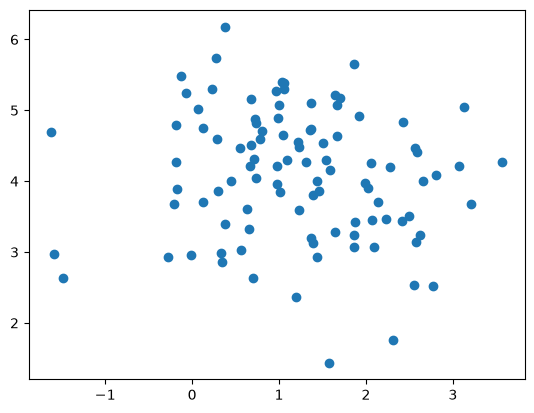

In [3]:
## plot samples
to_plot = samples.numpy()
plt.scatter(to_plot[:,0], to_plot[:,1])

## Metropolis Monte-Carlo Sampling

In [4]:
## need a prior p(\theta) (let's choose N(0,1))
## need a distribution type for p(y|\theta) (normal dist)
## need a distribution for the jump distribution - N(0, 1/5)
prior_dist = dist.MultivariateNormal(
    loc = torch.Tensor([0, 0]),
    covariance_matrix=torch.eye(2)
)

initial_means = prior_dist.sample((1,))
print(initial_means)

jumping_dist = dist.MultivariateNormal(
    loc = initial_means,
    covariance_matrix=torch.eye(2)
)

next_means = jumping_dist.sample((1,))

print(next_means)

## calculate p(y | next_means)
## log (p(next_means)) + sum(log(p(y | next_means)))
initial_prior_logprob = prior_dist.log_prob(initial_means)
next_prior_logprob = prior_dist.log_prob(next_means)

initial_likelihood_dist = dist.MultivariateNormal(loc = initial_means,covariance_matrix=torch.eye(2))
initial_likelihood_logprob = initial_likelihood_dist.log_prob(samples)

next_likelihood_dist = dist.MultivariateNormal(loc = next_means, covariance_matrix=torch.eye(2))
next_likelihood_logprob = next_likelihood_dist.log_prob(samples)

next_p = next_prior_logprob + next_likelihood_logprob.sum()
initial_p = initial_prior_logprob + initial_likelihood_logprob.sum()
r = next_prior_logprob + next_likelihood_logprob.sum() - (initial_prior_logprob + initial_likelihood_logprob.sum())
if r >= torch.log(dist.Uniform(0, 1).sample((1,))):
    

SyntaxError: incomplete input (36375353.py, line 36)

In [ ]:
def sample_proposal_params(
        current_params: torch.Tensor,
        scale_value: float = .2
    ) -> torch.Tensor:
    return dist.MultivariateNormal(
        loc=current_params,
        covariance_matrix=scale_value * torch.eye(2)
    ).sample((1,)).squeeze()

def calc_loglik(
        samples: torch.Tensor, 
        params: torch.Tensor,
        prior_dist: dist.Distribution,
    ) -> torch.Tensor:
    loglikelihood_dist = dist.MultivariateNormal(loc=params, covariance_matrix=torch.eye(2))
    return prior_dist.log_prob(params) + loglikelihood_dist.log_prob(samples).sum()

def calc_r(
        proposal_loglik: torch.Tensor,
        current_loglik: torch.Tensor
    ) -> torch.Tensor:
    return proposal_loglik - current_loglik

def choose_next_params(
        proposal_params: torch.Tensor,
        current_params: torch.Tensor,
        r: torch.Tensor
    ) -> torch.Tensor:
    unif_sample = torch.log(dist.Uniform(0, 1).sample((1,)))
    if r >= unif_sample:
        next_params = proposal_params
    else:
        next_params = current_params
    return next_params


In [ ]:
## algo setup
num_iters = 100
num_chains = 10

## prior distribution
prior_dist = dist.MultivariateNormal(
    loc = torch.Tensor([0, 0]),
    covariance_matrix=10*torch.eye(2)
)

param_history = torch.empty((num_chains, num_iters + 1, 2))
for chain in range(num_chains):
    current_params = prior_dist.sample((1,)).squeeze()
    param_history[chain, 0, :] = current_params
    for t in range(num_iters):

        proposal_params = sample_proposal_params(
            current_params=current_params
        )
        proposal_loglik = calc_loglik(
            samples = samples,
            params = proposal_params,
            prior_dist=prior_dist
        )
        current_loglik = calc_loglik(
            samples = samples,
            params = current_params,
            prior_dist = prior_dist
        )
                
        r = calc_r(
            proposal_loglik=proposal_loglik, 
            current_loglik=current_loglik
        )

        # set current params to next params
        current_params = choose_next_params(
            proposal_params=proposal_params,
            current_params=current_params,
            r=r
        )
        param_history[chain, t+1, :] = current_params



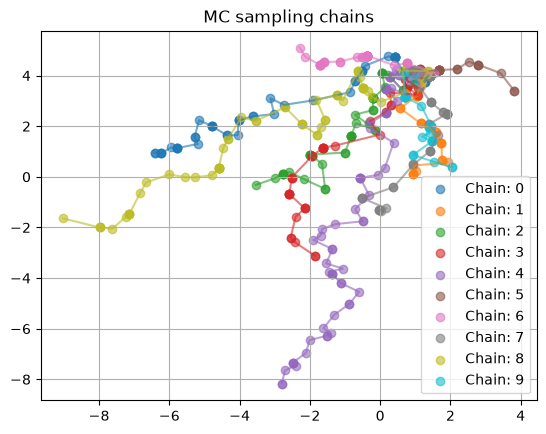

In [ ]:
for c in range(num_chains):
    to_plot = param_history[c, :, :].numpy()
    plt.plot(to_plot[:, 0], to_plot[:, 1], alpha = .6)
    plt.scatter(to_plot[:, 0], to_plot[:, 1], label = f"Chain: {c}", alpha = .6)
    plt.grid(True)

plt.title("MC sampling chains")
plt.legend()
plt.show();

In [ ]:
def plot_error_rate(history: torch.Tensor, num_chains: int):
    for c in range(num_chains):
        to_plot = history[c, :, :].numpy()
        error = ((to_plot - torch.Tensor([1,4]).numpy())**2).sum(axis=1)
        plt.plot(error, label = f"Chain: {c}")

    plt.legend()
    plt.show();

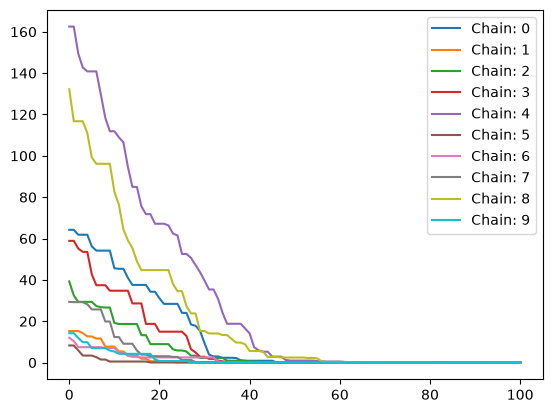

In [ ]:
for c in range(num_chains):
    to_plot = param_history[c, :, :].numpy()
    error = ((to_plot - torch.Tensor([1,4]).numpy())**2).sum(axis=1)
    plt.plot(error, label = f"Chain: {c}")

plt.legend()
plt.show();

## Create Metropolis-Monte-Carlo Class
Got Claude to give me feedback. It proposed a class design as shown below:

In [ ]:
# from typing import Callable

# class MetropolisSampler:
#     """Random-walk Metropolis with a symmetric Gaussian proposal"""

#     def __init__(
#             self,
#             log_prob_fn: Callable[[torch.Tensor], torch.Tensor],
#             dim: int,
#             init_dist: dist.Distribution,
#             proposal_std: float = 0.45,
#             seed: int = 42
#     ):
#         self.log_prob_fn = log_prob_fn
#         self.dim = dim
#         self.proposal_std = proposal_std
#         self.init_dist = init_dist
#         torch.manual_seed(seed)

#     def calc_gelman_rubin(self, num_iters: int, burnin: int, results: torch.Tensor) -> torch.Tensor:
#         L = num_iters - burnin

#         ## calculate mean by chains
#         chain_means = results.mean(dim=1)
#         grand_mean = chain_means.mean(dim=0)

#         ## between chain variance
#         B = (L/(num_chains - 1)) * torch.pow(chain_means - grand_mean,2).sum(dim=0)

#         within_chain_variance = (1/(L - 1)) * torch.pow(results - chain_means.unsqueeze(1), 2).sum(dim=1)
#         W = within_chain_variance.mean(dim=0)
#         var_hat = ((L-1)/L)*W + (1/L) * B
#         gelman_rubin_statistic = torch.sqrt(var_hat/W)
#         return gelman_rubin_statistic

#     def proposal_fn(self, current_params: torch.Tensor) -> torch.Tensor:
#         return current_params + self.proposal_std * torch.randn_like(current_params)
    
#     def run(self, num_iters: int, num_chains: int, burnin: int):
#         assert burnin < num_iters, f"burnin (got {burnin}) must be less than num_iters (got {num_iters})"
#         history = torch.empty((num_chains, num_iters + 1, self.dim))
#         accepts = torch.zeros(num_chains)
#         gelman_rubin = torch.zeros((num_iters - (burnin + 2), self.dim))

#         current_params = self.init_dist.sample((num_chains,)).reshape(num_chains, self.dim)
#         current_lp = self.log_prob_fn(current_params)
#         history[:, 0, :] = current_params
#         for t in range(num_iters):
#             proposal_params = self.proposal_fn(current_params=current_params)
#             proposal_lp = self.log_prob_fn(proposal_params)
#             log_u = torch.log(torch.rand(num_chains))
#             accept = (proposal_lp - current_lp) >= log_u

#             current_params = torch.where(accept.unsqueeze(-1), proposal_params, current_params)
#             current_lp = torch.where(accept, proposal_lp, current_lp)
#             accepts += accept
#             history[:, t + 1, :] = current_params

#             if t > burnin + 1:
#                 gelman_rubin[t - (burnin + 2), :] = self.calc_gelman_rubin(num_iters=t, burnin=burnin, results=history)

        
#         self.acceptance_rate = (accepts / num_iters)
#         self.results = history[:, (burnin + 1):, :]
#         self.gelman_rubin = gelman_rubin
#         return history
    
# def make_gaussian_mean_model(samples, prior_dist, like_cov = None):

#     like_cov = torch.eye(samples.shape[-1]) if like_cov is None else like_cov

#     def log_prob(params):
#         prior_lp = prior_dist.log_prob(params)
#         like = dist.MultivariateNormal(params, like_cov)
#         like_lp = like.log_prob(samples.unsqueeze(1)).sum(dim=0)
#         return prior_lp + like_lp
    
#     return log_prob

# prior = dist.MultivariateNormal(torch.tensor([-1.0, 6.0]), 10.0 * torch.eye(2))
# model = make_gaussian_mean_model(samples, prior)
# sampler = MetropolisSampler(
#     model, 
#     dim=2, 
#     proposal_std=0.45, 
#     init_dist=prior, 
#     seed=0
# )
# history = sampler.run(num_iters=100, num_chains=10, burnin=50)
# print(sampler.acceptance_rate)   # tune proposal_std toward ~0.2–0.4
# print(sampler.gelman_rubin[-1])


tensor([0.1600, 0.1000, 0.1500, 0.2100, 0.0600, 0.1600, 0.2200, 0.0600, 0.2100,
        0.1700])
tensor([1.0532, 1.0689])


In [ ]:
# ## Generate Synthetic Data
# n_samples = 5000
# base_dist = dist.MultivariateNormal(
#     loc=torch.Tensor([1, 4]), 
#     covariance_matrix=torch.eye(2)
# )

# samples = base_dist.sample((n_samples,))

# prior = dist.MultivariateNormal(torch.tensor([-1.0, 6.0]), 10.0 * torch.eye(2))
# model = make_gaussian_mean_model(samples, prior)
# sampler = MetropolisSampler(
#     model, 
#     dim=2, 
#     proposal_std=0.03, 
#     init_dist=prior, 
#     seed=0
# )

# num_iters, num_chains, burnin = 10000, 10, 5000
# history = sampler.run(num_iters=num_iters, num_chains=num_chains, burnin=burnin)
# print(sampler.acceptance_rate)   # tune proposal_std toward ~0.2–0.4
# print(sampler.gelman_rubin[-1])

tensor([0.2841, 0.2784, 0.2785, 0.2903, 0.2819, 0.2756, 0.2865, 0.2786, 0.2826,
        0.2777])
tensor([1.0103, 1.0089])


In [2]:
from samplers.metropolis_sampler import MetropolisSampler

def make_gaussian_mean_model(samples, prior_dist, like_cov = None):

    like_cov = torch.eye(samples.shape[-1]) if like_cov is None else like_cov

    def log_prob(params):
        prior_lp = prior_dist.log_prob(params)
        like = dist.MultivariateNormal(params, like_cov)
        like_lp = like.log_prob(samples.unsqueeze(1)).sum(dim=0)
        return prior_lp + like_lp
    
    return log_prob

## Generate Synthetic Data
n_samples = 5000
base_dist = dist.MultivariateNormal(
    loc=torch.Tensor([1, 4]), 
    covariance_matrix=torch.eye(2)
)

samples = base_dist.sample((n_samples,))

prior = dist.MultivariateNormal(torch.tensor([-1.0, 6.0]), 10.0 * torch.eye(2))
model = make_gaussian_mean_model(samples, prior)
sampler = MetropolisSampler(
    model, 
    dim=2, 
    proposal_std=0.03, 
    init_dist=prior, 
    seed=0
)

num_iters, num_chains, burnin = 10000, 10, 5000
history = sampler.run(num_iters=num_iters, num_chains=num_chains, burnin=burnin)
print(sampler.acceptance_rate)   # tune proposal_std toward ~0.2–0.4
print(sampler.gelman_rubin[-1])

tensor([0.2856, 0.2840, 0.2821, 0.2882, 0.2723, 0.2724, 0.2868, 0.2811, 0.2768,
        0.2816])
tensor([1.0011, 1.0011])


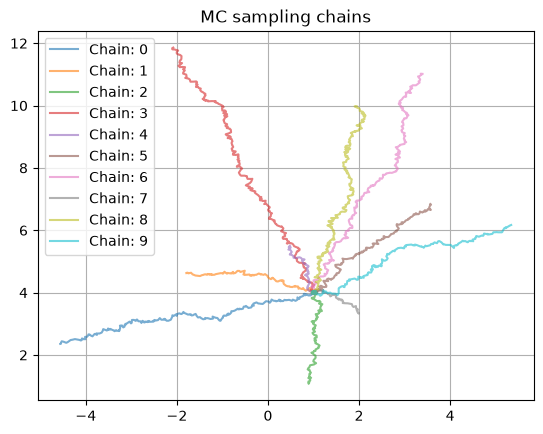

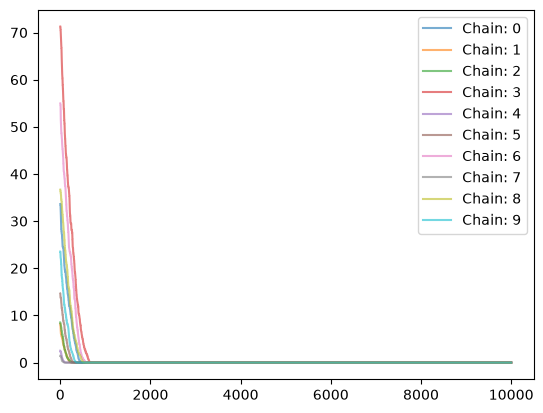

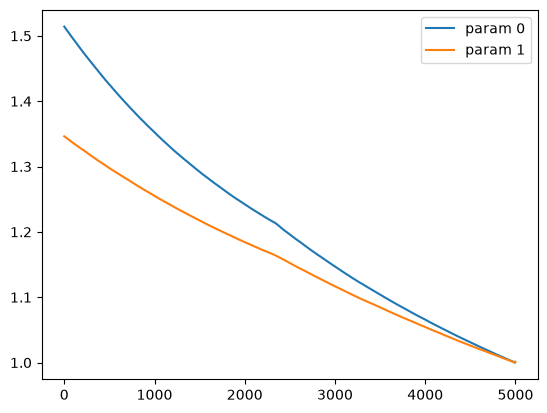

In [3]:
def plot_gelman_rubin(gelman_rubin: torch.Tensor):
    num_params = gelman_rubin.size()[-1]
    to_plot = gelman_rubin.numpy()
    for p in range(num_params):
        plt.plot(to_plot[:, p], label=f"param {p}")
    plt.legend()
    plt.show()

def plot_error_rate(history: torch.Tensor, num_chains: int):
    for c in range(num_chains):
        to_plot = history[c, :, :].numpy()
        error = ((to_plot - torch.Tensor([1,4]).numpy())**2).sum(axis=1)
        plt.plot(error, label = f"Chain: {c}", alpha = 0.6)

    plt.legend()
    plt.show();

def plot_2d_convergence(history: torch.Tensor, num_chains:int):
    for c in range(num_chains):
        to_plot = history[c, :, :].numpy()
        plt.plot(to_plot[:, 0], to_plot[:, 1], alpha = .6, label = f"Chain: {c}")
        # plt.scatter(to_plot[:, 0], to_plot[:, 1], label = f"Chain: {c}", alpha = .3)
        plt.grid(True)

    plt.title("MC sampling chains")
    plt.legend()
    plt.show();

plot_2d_convergence(history, num_chains)
plot_error_rate(history, num_chains)
plot_gelman_rubin(sampler.gelman_rubin)

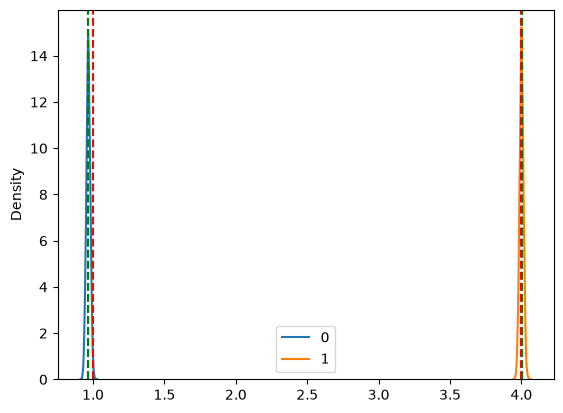

In [ ]:
results_to_plot =  sampler.results.reshape(num_chains * burnin, 2).numpy()
sns.kdeplot(
    data = results_to_plot
)
plt.axvline(x = results_to_plot[:,0].mean(), linestyle = '--')
plt.axvline(x = results_to_plot[:,1].mean(), linestyle = '--')
plt.axvline(x = 1.0, c = 'red', linestyle = '--')
plt.axvline(x = 4.0, c = 'red', linestyle = '--')
plt.axvline(x = samples[:,0].mean().numpy(), c = 'green', linestyle = '--')
plt.axvline(x = samples[:,1].mean().numpy(), c = 'green', linestyle = '--')

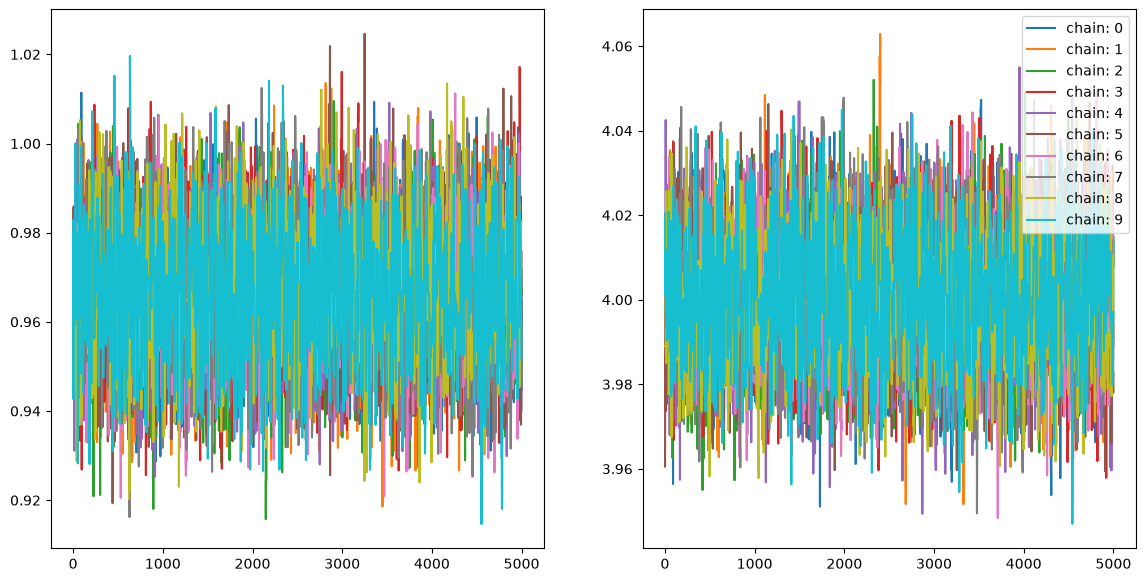

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (14, 7))
for c in range(num_chains):
    to_plot = sampler.results[c, :, :].numpy()
    ax[0].plot(to_plot[:, 0], label = f"chain: {c}")
    ax[1].plot(to_plot[:, 1], label = f"chain: {c}")

plt.legend()
plt.show();


In [ ]:
## monte carlo standard errors

monte_carlo_standard_errors = torch.sqrt(torch.pow(sampler.results - sampler.results.mean(dim=(0,1)), 2).sum(dim=(0,1)) / (num_chains - 1)) / torch.sqrt(torch.Tensor([num_chains]))

tensor([0.3334, 0.3345])

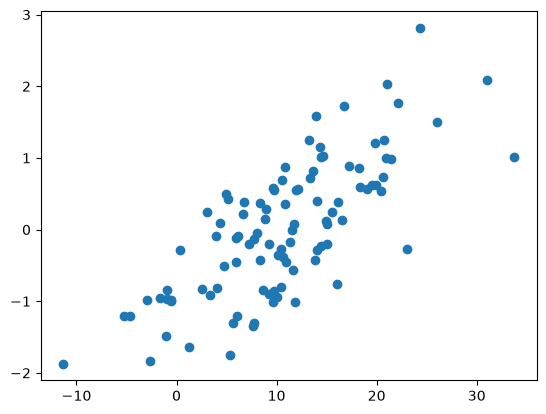

In [ ]:
beta0 = 10
beta1 = 5
x = torch.randn(size=(n_samples,))
y = dist.Normal(loc=beta0 + beta1 * x, scale=5)
samples = torch.stack([y.sample(),x], dim=1)
plt.scatter(samples.numpy()[:,0], samples.numpy()[:,1])


In [ ]:
def make_gaussian_lr_model(samples, prior_dist, scale = None):

    scale = 1.0 if scale is None else scale

    def log_prob(params):
        prior_lp = prior_dist.log_prob(params).sum(dim=-1)
        like = dist.Normal(params[:, 0].unsqueeze(1) + params[:, 1].unsqueeze(1) * samples[:,1], scale)
        like_lp = like.log_prob(samples[:, 0]).sum(dim=-1)
        return prior_lp + like_lp
    
    return log_prob

prior = dist.Normal(torch.tensor([0.,0.]), torch.tensor([10.,10.]))
model = make_gaussian_lr_model(samples, prior)
sampler = MetropolisSampler(
    model, 
    dim=2, 
    proposal_std=0.05, 
    init_dist=prior, 
    seed=0
)
history = sampler.run(num_iters=1000, num_chains=10)
print(sampler.acceptance_rate)   # tune proposal_std toward ~0.2–0.4

tensor([0.5210, 0.5410, 0.5220, 0.5280, 0.6700, 0.6900, 0.6530, 0.5990, 0.6970,
        0.6640])


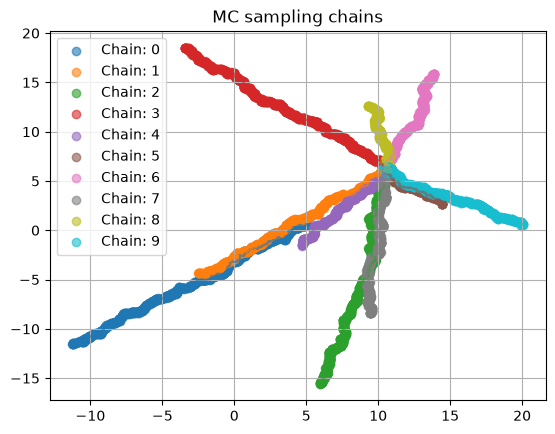

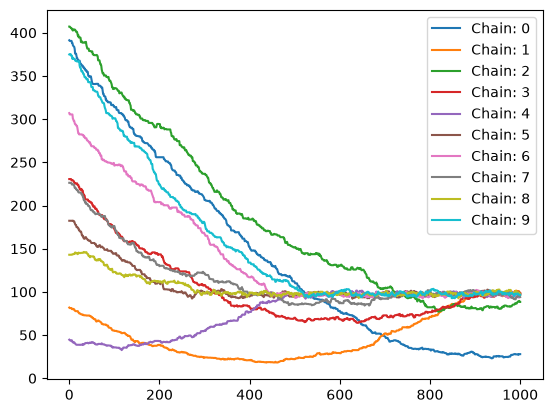

In [ ]:
plot_2d_convergence(history, num_chains)
plot_error_rate(history, num_chains)